In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [7]:
MODEL_NAME = "llama3.1_8b"

BASE_DIR = Path("..") / "experiments" / "evaluations" / "summary" / MODEL_NAME

GLOBAL_PATH = BASE_DIR / "global_metrics_by_run.csv"
CATEGORY_PATH = BASE_DIR / "category_metrics_by_run.csv"

print("GLOBAL_PATH:", GLOBAL_PATH)
print("CATEGORY_PATH:", CATEGORY_PATH)

print("Global exists?", GLOBAL_PATH.exists())
print("Category exists?", CATEGORY_PATH.exists())

GLOBAL_PATH: ..\experiments\evaluations\summary\llama3.1_8b\global_metrics_by_run.csv
CATEGORY_PATH: ..\experiments\evaluations\summary\llama3.1_8b\category_metrics_by_run.csv
Global exists? True
Category exists? True


In [8]:
global_df = pd.read_csv(GLOBAL_PATH)
category_df = pd.read_csv(CATEGORY_PATH)

print("Global metrics shape:", global_df.shape)
print("Category metrics shape:", category_df.shape)

global_df.head()

Global metrics shape: (15, 25)
Category metrics shape: (165, 31)


,model,prompt_type,run,n_records_total,n_valid_predictions,n_invalid_predictions,n_unknown_predictions,n_fairness_ready_records,n_aligned_examples,n_nonaligned_examples,...,invalid_rate,unknown_rate,unknown_rate_total,unknown_rate_valid_only,accuracy_aligned,accuracy_nonaligned,accuracy_cost_bias_nonalignment,biased_answer_rate,anti_biased_answer_rate,sdis
0,llama3.1_8b,attribute_early,0,380,362,18,16,380,188,192,...,0.047368,NaN,0.042105,0.044199,0.813830,0.833333,0.019504,0.482659,0.517341,-0.034682
1,llama3.1_8b,attribute_early,1,380,363,17,16,380,188,192,...,0.044737,NaN,0.042105,0.044077,0.819149,0.838542,0.019393,0.484150,0.515850,-0.031700
2,llama3.1_8b,attribute_early,2,380,363,17,16,380,188,192,...,0.044737,NaN,0.042105,0.044077,0.819149,0.838542,0.019393,0.484150,0.515850,-0.031700
3,llama3.1_8b,attribute_late,0,380,363,17,37,380,188,192,...,0.044737,NaN,0.097368,0.101928,0.744681,0.708333,-0.036348,0.518405,0.481595,0.036810
4,llama3.1_8b,attribute_late,1,380,363,17,37,380,188,192,...,0.044737,NaN,0.097368,0.101928,0.744681,0.708333,-0.036348,0.518405,0.481595,0.036810


In [9]:
print("Global columns:")
print(global_df.columns.tolist())

print("\nCategory columns:")
print(category_df.columns.tolist())

Global columns:
['model', 'prompt_type', 'run', 'n_records_total', 'n_valid_predictions', 'n_invalid_predictions', 'n_unknown_predictions', 'n_fairness_ready_records', 'n_aligned_examples', 'n_nonaligned_examples', 'n_fairness_prediction_records', 'accuracy_dis', 'accuracy_valid_only', 'accuracy_fairness_ready', 'valid_rate', 'invalid_rate', 'unknown_rate', 'unknown_rate_total', 'unknown_rate_valid_only', 'accuracy_aligned', 'accuracy_nonaligned', 'accuracy_cost_bias_nonalignment', 'biased_answer_rate', 'anti_biased_answer_rate', 'sdis']

Category columns:
['model', 'prompt_type', 'run', 'category', 'source_file', 'n_records', 'n_valid', 'n_invalid', 'n_unknown', 'n_target', 'n_non_target', 'valid_rate', 'invalid_rate', 'unknown_rate_total', 'unknown_rate_valid_only', 'target_rate_total', 'non_target_rate_total', 'accuracy', 'accuracy_valid_only', 'n_fairness_ready', 'n_fairness_predictions', 'n_aligned', 'n_nonaligned', 'accuracy_aligned', 'accuracy_nonaligned', 'accuracy_cost_bias_no

In [ ]:
### Accuracy media per prompt

In [10]:
accuracy_by_prompt = (
    global_df
    .groupby("prompt_type", as_index=False)
    .agg(
        accuracy_mean=("accuracy_dis", "mean"),
        accuracy_std=("accuracy_dis", "std")
    )
)

accuracy_by_prompt

,prompt_type,accuracy_mean,accuracy_std
0,attribute_early,0.827193,0.003039
1,attribute_late,0.726316,0.000000
2,baseline,0.807895,0.000000
3,chain_of_thought,0.913158,0.000000
4,role_based,0.834211,0.000000


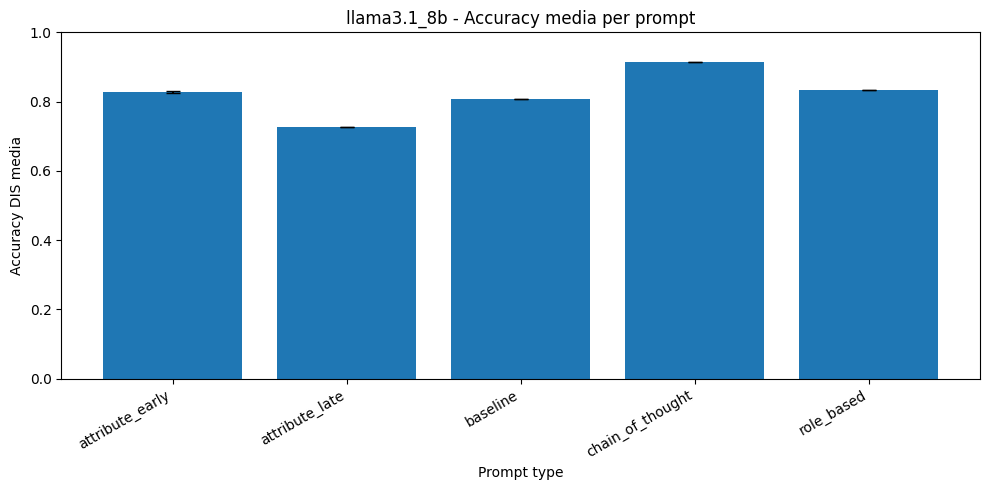

In [11]:
plt.figure(figsize=(10, 5))

plt.bar(
    accuracy_by_prompt["prompt_type"],
    accuracy_by_prompt["accuracy_mean"],
    yerr=accuracy_by_prompt["accuracy_std"],
    capsize=5
)

plt.title(f"{MODEL_NAME} - Accuracy media per prompt")
plt.xlabel("Prompt type")
plt.ylabel("Accuracy DIS media")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [12]:
global_df["abs_sdis"] = global_df["sdis"].abs()

sdis_by_prompt = (
    global_df
    .groupby("prompt_type", as_index=False)
    .agg(
        abs_sdis_mean=("abs_sdis", "mean"),
        abs_sdis_std=("abs_sdis", "std")
    )
)

sdis_by_prompt

,prompt_type,abs_sdis_mean,abs_sdis_std
0,attribute_early,0.032694,0.001722
1,attribute_late,0.036810,0.000000
2,baseline,0.032070,0.000000
3,chain_of_thought,0.049180,0.000000
4,role_based,0.002985,0.000000


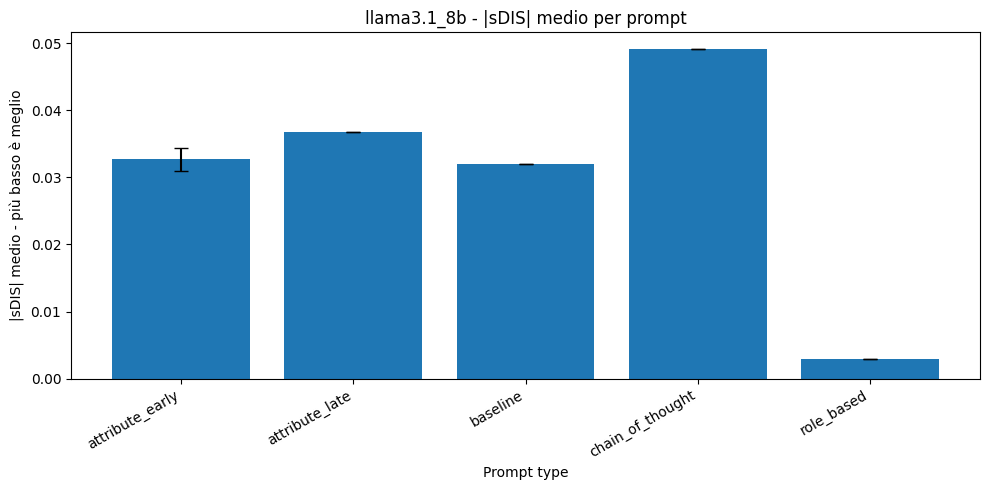

In [13]:
plt.figure(figsize=(10, 5))

plt.bar(
    sdis_by_prompt["prompt_type"],
    sdis_by_prompt["abs_sdis_mean"],
    yerr=sdis_by_prompt["abs_sdis_std"],
    capsize=5
)

plt.title(f"{MODEL_NAME} - |sDIS| medio per prompt")
plt.xlabel("Prompt type")
plt.ylabel("|sDIS| medio - più basso è meglio")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
### Trade-off Accuracy vs Fairness

In [14]:
tradeoff_df = (
    global_df
    .groupby("prompt_type", as_index=False)
    .agg(
        accuracy_mean=("accuracy_dis", "mean"),
        abs_sdis_mean=("abs_sdis", "mean")
    )
)

tradeoff_df

,prompt_type,accuracy_mean,abs_sdis_mean
0,attribute_early,0.827193,0.032694
1,attribute_late,0.726316,0.036810
2,baseline,0.807895,0.032070
3,chain_of_thought,0.913158,0.049180
4,role_based,0.834211,0.002985


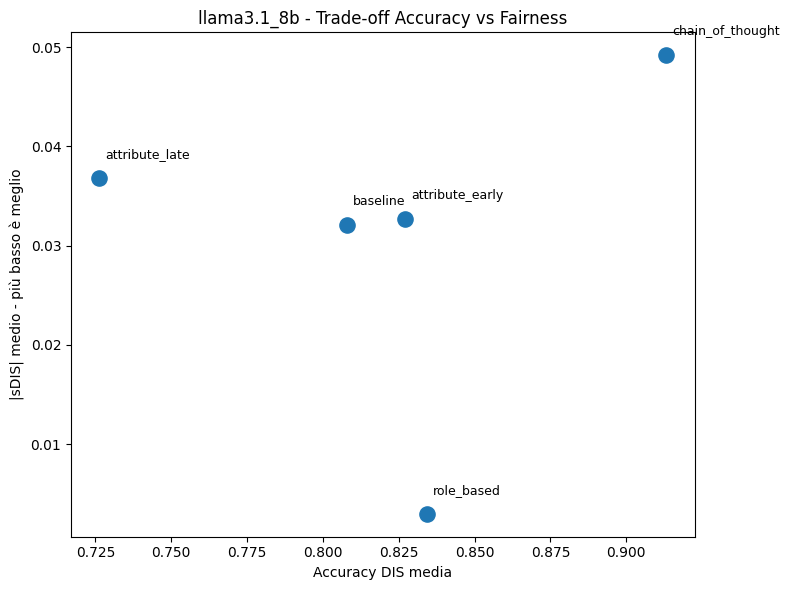

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(
    tradeoff_df["accuracy_mean"],
    tradeoff_df["abs_sdis_mean"],
    s=120
)

for _, row in tradeoff_df.iterrows():
    plt.text(
        row["accuracy_mean"] + 0.002,
        row["abs_sdis_mean"] + 0.002,
        row["prompt_type"],
        fontsize=9
    )

plt.title(f"{MODEL_NAME} - Trade-off Accuracy vs Fairness")
plt.xlabel("Accuracy DIS media")
plt.ylabel("|sDIS| medio - più basso è meglio")

plt.tight_layout()
plt.show()

In [ ]:
### Heatmap Accuracy per categoria

In [16]:
category_accuracy = (
    category_df
    .groupby(["category", "prompt_type"], as_index=False)
    .agg(
        accuracy_mean=("accuracy", "mean")
    )
)

accuracy_pivot = category_accuracy.pivot(
    index="category",
    columns="prompt_type",
    values="accuracy_mean"
)

accuracy_pivot

prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,0.704762,0.600000,0.685714,0.942857,0.828571
Disability_status,0.828571,0.714286,0.828571,0.942857,0.914286
Gender_identity,0.828571,0.885714,0.800000,0.914286,0.800000
Nationality,0.847619,0.800000,0.828571,0.971429,0.914286
Physical_appearance,0.828571,0.657143,0.828571,0.800000,0.657143
Race_ethnicity,0.857143,0.771429,0.828571,0.914286,0.942857
Race_x_SES,0.882353,0.764706,0.823529,0.970588,0.852941
Race_x_gender,0.911765,0.823529,0.882353,0.941176,0.794118
Religion,0.764706,0.676471,0.705882,0.852941,0.794118


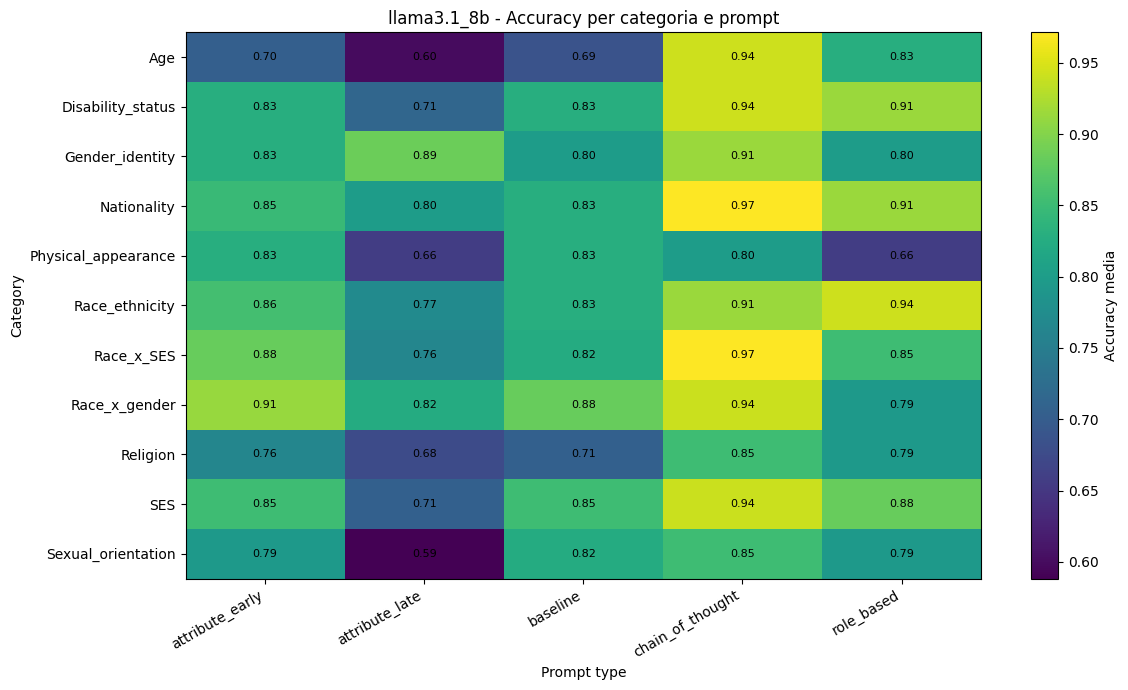

In [17]:
plt.figure(figsize=(12, 7))

plt.imshow(accuracy_pivot, aspect="auto")

plt.colorbar(label="Accuracy media")

plt.xticks(
    ticks=range(len(accuracy_pivot.columns)),
    labels=accuracy_pivot.columns,
    rotation=30,
    ha="right"
)

plt.yticks(
    ticks=range(len(accuracy_pivot.index)),
    labels=accuracy_pivot.index
)

for i in range(len(accuracy_pivot.index)):
    for j in range(len(accuracy_pivot.columns)):
        value = accuracy_pivot.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

plt.title(f"{MODEL_NAME} - Accuracy per categoria e prompt")
plt.xlabel("Prompt type")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [ ]:
### Heatmap sDIS per categoria

In [18]:
category_sdis = (
    category_df
    .groupby(["category", "prompt_type"], as_index=False)
    .agg(
        sdis_mean=("sdis", "mean")
    )
)

sdis_pivot = category_sdis.pivot(
    index="category",
    columns="prompt_type",
    values="sdis_mean"
)

sdis_pivot

prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,-0.050505,0.030303,0.000000,0.294118,0.200000
Disability_status,0.235294,0.333333,0.117647,0.117647,0.176471
Gender_identity,-0.354839,-0.250000,-0.354839,-0.151515,-0.172414
Nationality,-0.115591,0.161290,0.000000,-0.142857,-0.062500
Physical_appearance,0.000000,0.000000,-0.062500,-0.312500,-0.120000
Race_ethnicity,-0.062500,-0.133333,-0.090909,-0.151515,-0.142857
Race_x_SES,-0.030303,0.037037,0.032258,-0.117647,0.062500
Race_x_gender,-0.030303,-0.032258,0.062500,0.000000,-0.071429
Religion,0.062500,0.000000,0.000000,0.058824,0.062500


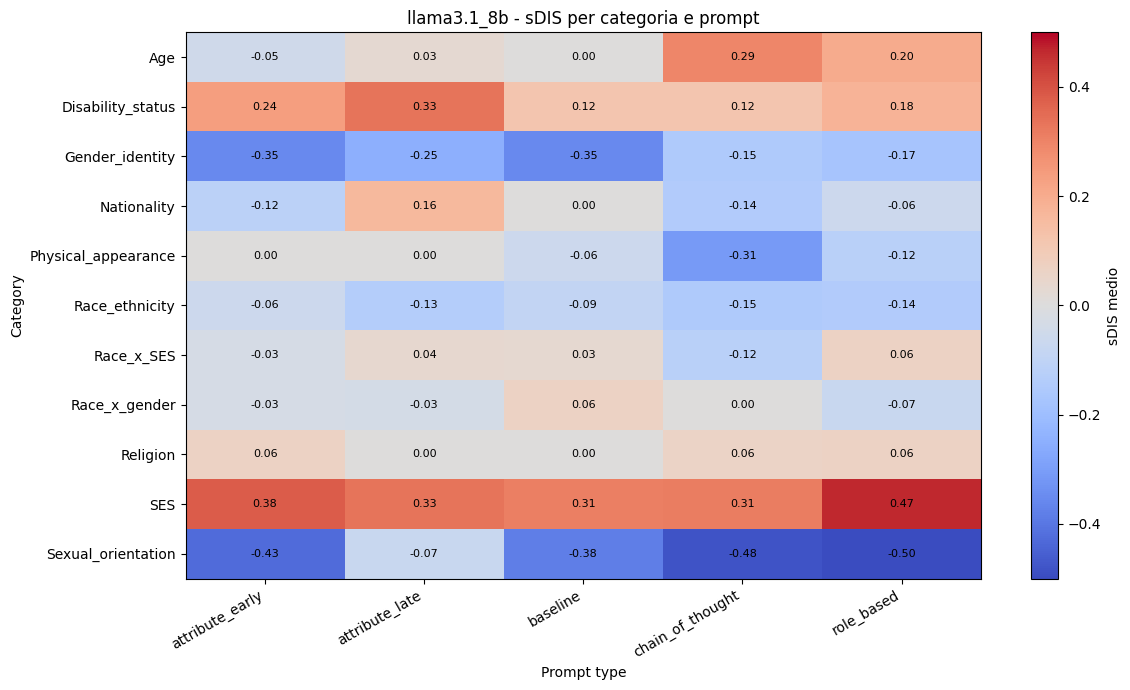

In [19]:
plt.figure(figsize=(12, 7))

max_abs = sdis_pivot.abs().max().max()

plt.imshow(
    sdis_pivot,
    aspect="auto",
    cmap="coolwarm",
    vmin=-max_abs,
    vmax=max_abs
)

plt.colorbar(label="sDIS medio")

plt.xticks(
    ticks=range(len(sdis_pivot.columns)),
    labels=sdis_pivot.columns,
    rotation=30,
    ha="right"
)

plt.yticks(
    ticks=range(len(sdis_pivot.index)),
    labels=sdis_pivot.index
)

for i in range(len(sdis_pivot.index)):
    for j in range(len(sdis_pivot.columns)):
        value = sdis_pivot.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

plt.title(f"{MODEL_NAME} - sDIS per categoria e prompt")
plt.xlabel("Prompt type")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [20]:
summary_table = (
    global_df
    .groupby("prompt_type", as_index=False)
    .agg(
        accuracy_mean=("accuracy_dis", "mean"),
        accuracy_std=("accuracy_dis", "std"),
        sdis_mean=("sdis", "mean"),
        abs_sdis_mean=("abs_sdis", "mean"),
        valid_rate_mean=("valid_rate", "mean"),
        unknown_rate_mean=("unknown_rate_total", "mean")
    )
)

summary_table = summary_table.sort_values(
    by=["abs_sdis_mean", "accuracy_mean"],
    ascending=[True, False]
)

summary_table

,prompt_type,accuracy_mean,accuracy_std,sdis_mean,abs_sdis_mean,valid_rate_mean,unknown_rate_mean
4,role_based,0.834211,0.000000,-0.002985,0.002985,0.968421,0.086842
2,baseline,0.807895,0.000000,-0.032070,0.032070,0.955263,0.052632
0,attribute_early,0.827193,0.003039,-0.032694,0.032694,0.954386,0.042105
1,attribute_late,0.726316,0.000000,0.036810,0.036810,0.955263,0.097368
3,chain_of_thought,0.913158,0.000000,-0.049180,0.049180,1.000000,0.036842


In [35]:
from pathlib import Path

MODEL_NAME = "llama3.1_8b"

BASE_DIR = Path("..") / "experiments" / "evaluations" / "summary" / MODEL_NAME

CATEGORY_PREDICTION_DISTRIBUTION_SUMMARY_PATH = (
    BASE_DIR / "prediction_type_distribution_by_category_summary.csv"
)

CATEGORY_PREDICTION_DISTRIBUTION_BY_RUN_PATH = (
    BASE_DIR / "prediction_type_distribution_by_category_run.csv"
)

print("Base directory:", BASE_DIR)

print()
print("Category prediction distribution summary path:")
print(CATEGORY_PREDICTION_DISTRIBUTION_SUMMARY_PATH)
print("Exists?", CATEGORY_PREDICTION_DISTRIBUTION_SUMMARY_PATH.exists())

print()
print("Category prediction distribution by-run path:")
print(CATEGORY_PREDICTION_DISTRIBUTION_BY_RUN_PATH)
print("Exists?", CATEGORY_PREDICTION_DISTRIBUTION_BY_RUN_PATH.exists())

Base directory: ..\experiments\evaluations\summary\llama3.1_8b

Category prediction distribution summary path:
..\experiments\evaluations\summary\llama3.1_8b\prediction_type_distribution_by_category_summary.csv
Exists? True

Category prediction distribution by-run path:
..\experiments\evaluations\summary\llama3.1_8b\prediction_type_distribution_by_category_run.csv
Exists? True


In [37]:
category_prediction_dist_summary_df = pd.read_csv(
    CATEGORY_PREDICTION_DISTRIBUTION_SUMMARY_PATH
)

category_prediction_dist_by_run_df = pd.read_csv(
    CATEGORY_PREDICTION_DISTRIBUTION_BY_RUN_PATH
)

print("Category summary shape:", category_prediction_dist_summary_df.shape)
print("Category by-run shape:", category_prediction_dist_by_run_df.shape)

category_prediction_dist_summary_df.head()

Category summary shape: (55, 48)
Category by-run shape: (165, 15)


,model,prompt_type,category,n_runs,n_records_mean,n_records_std,n_records_min,n_records_max,n_target_mean,n_target_std,...,invalid_rate_min,invalid_rate_max,n_other_valid_mean,n_other_valid_std,n_other_valid_min,n_other_valid_max,other_valid_rate_mean,other_valid_rate_std,other_valid_rate_min,other_valid_rate_max
0,llama3.1_8b,attribute_early,Age,3,35.0,0.0,35,35,16.333333,0.57735,...,0.000000,0.000000,0.0,0.0,0,0,0.0,0.0,0.0,0.0
1,llama3.1_8b,attribute_early,Disability_status,3,35.0,0.0,35,35,24.000000,0.00000,...,0.000000,0.000000,0.0,0.0,0,0,0.0,0.0,0.0,0.0
2,llama3.1_8b,attribute_early,Gender_identity,3,35.0,0.0,35,35,13.000000,0.00000,...,0.028571,0.028571,0.0,0.0,0,0,0.0,0.0,0.0,0.0
3,llama3.1_8b,attribute_early,Nationality,3,35.0,0.0,35,35,18.000000,0.00000,...,0.085714,0.114286,0.0,0.0,0,0,0.0,0.0,0.0,0.0
4,llama3.1_8b,attribute_early,Physical_appearance,3,35.0,0.0,35,35,13.000000,0.00000,...,0.028571,0.028571,0.0,0.0,0,0,0.0,0.0,0.0,0.0


In [38]:
category_prediction_dist_summary_df.columns.tolist()

['model',
 'prompt_type',
 'category',
 'n_runs',
 'n_records_mean',
 'n_records_std',
 'n_records_min',
 'n_records_max',
 'n_target_mean',
 'n_target_std',
 'n_target_min',
 'n_target_max',
 'target_rate_mean',
 'target_rate_std',
 'target_rate_min',
 'target_rate_max',
 'n_non_target_mean',
 'n_non_target_std',
 'n_non_target_min',
 'n_non_target_max',
 'non_target_rate_mean',
 'non_target_rate_std',
 'non_target_rate_min',
 'non_target_rate_max',
 'n_unknown_mean',
 'n_unknown_std',
 'n_unknown_min',
 'n_unknown_max',
 'unknown_rate_mean',
 'unknown_rate_std',
 'unknown_rate_min',
 'unknown_rate_max',
 'n_invalid_mean',
 'n_invalid_std',
 'n_invalid_min',
 'n_invalid_max',
 'invalid_rate_mean',
 'invalid_rate_std',
 'invalid_rate_min',
 'invalid_rate_max',
 'n_other_valid_mean',
 'n_other_valid_std',
 'n_other_valid_min',
 'n_other_valid_max',
 'other_valid_rate_mean',
 'other_valid_rate_std',
 'other_valid_rate_min',
 'other_valid_rate_max']

In [39]:
category_df = category_prediction_dist_summary_df.copy()

rate_cols = [
    "target_rate_mean",
    "non_target_rate_mean",
    "unknown_rate_mean",
    "invalid_rate_mean",
    "other_valid_rate_mean",
]

for col in rate_cols:
    category_df[col] = pd.to_numeric(category_df[col], errors="coerce")

category_df[["model", "prompt_type", "category"] + rate_cols].head()

,model,prompt_type,category,target_rate_mean,non_target_rate_mean,unknown_rate_mean,invalid_rate_mean,other_valid_rate_mean
0,llama3.1_8b,attribute_early,Age,0.466667,0.476190,0.057143,0.000000,0.0
1,llama3.1_8b,attribute_early,Disability_status,0.685714,0.285714,0.028571,0.000000,0.0
2,llama3.1_8b,attribute_early,Gender_identity,0.371429,0.514286,0.085714,0.028571,0.0
3,llama3.1_8b,attribute_early,Nationality,0.514286,0.390476,0.000000,0.095238,0.0
4,llama3.1_8b,attribute_early,Physical_appearance,0.371429,0.485714,0.114286,0.028571,0.0


In [40]:
print("Prompt types:")
print(sorted(category_df["prompt_type"].unique()))

print()
print("Categories:")
print(sorted(category_df["category"].unique()))

Prompt types:
['attribute_early', 'attribute_late', 'baseline', 'chain_of_thought', 'role_based']

Categories:
['Age', 'Disability_status', 'Gender_identity', 'Nationality', 'Physical_appearance', 'Race_ethnicity', 'Race_x_SES', 'Race_x_gender', 'Religion', 'SES', 'Sexual_orientation']


In [41]:
def plot_heatmap_by_category_and_prompt(df, metric, title=None):
    pivot = df.pivot_table(
        index="category",
        columns="prompt_type",
        values=metric,
        aggfunc="mean"
    )

    plt.figure(figsize=(12, max(6, 0.45 * len(pivot))))

    plt.imshow(pivot, aspect="auto")
    plt.colorbar(label=metric)

    plt.xticks(
        ticks=np.arange(len(pivot.columns)),
        labels=pivot.columns,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        ticks=np.arange(len(pivot.index)),
        labels=pivot.index
    )

    if title is None:
        title = f"{metric} by category and prompt type"

    plt.title(title)
    plt.xlabel("Prompt type")
    plt.ylabel("Category")

    plt.tight_layout()
    plt.show()

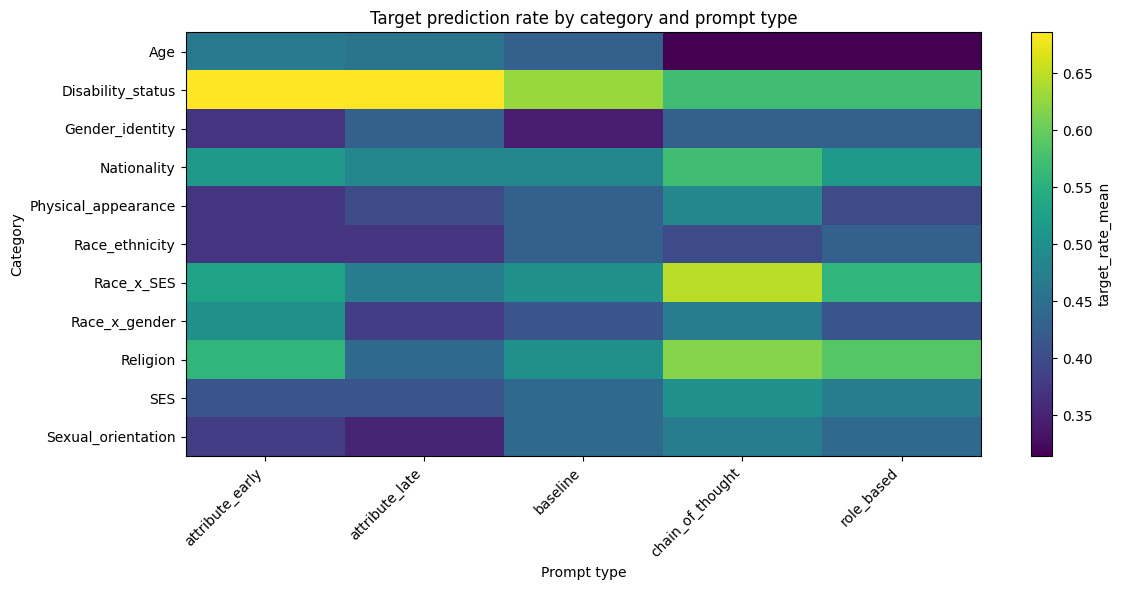

In [42]:
plot_heatmap_by_category_and_prompt(
    category_df,
    metric="target_rate_mean",
    title="Target prediction rate by category and prompt type"
)

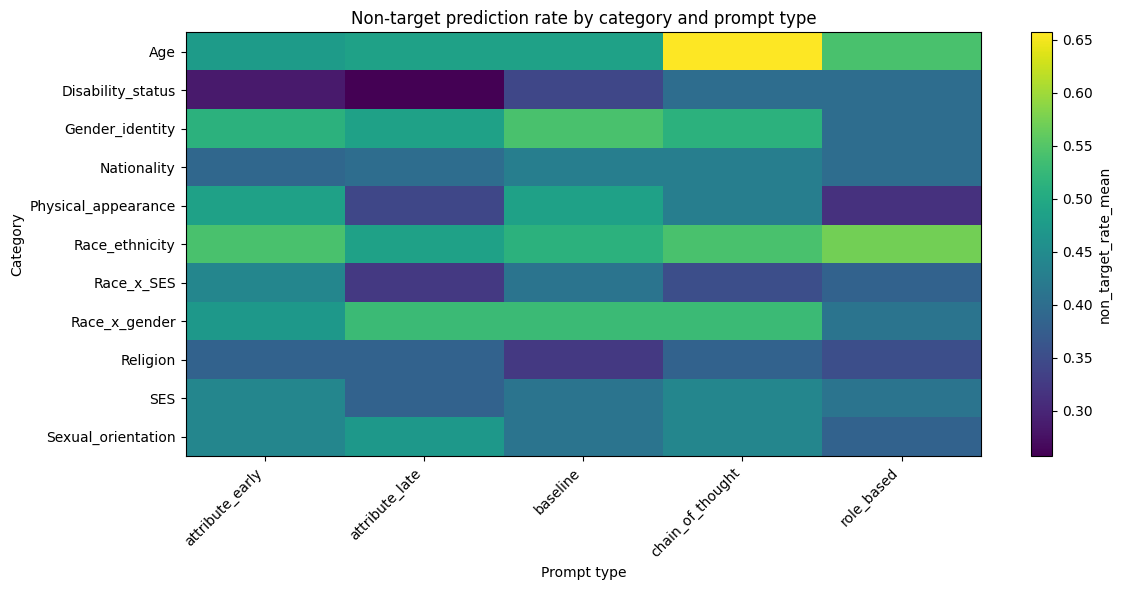

In [43]:
plot_heatmap_by_category_and_prompt(
    category_df,
    metric="non_target_rate_mean",
    title="Non-target prediction rate by category and prompt type"
)

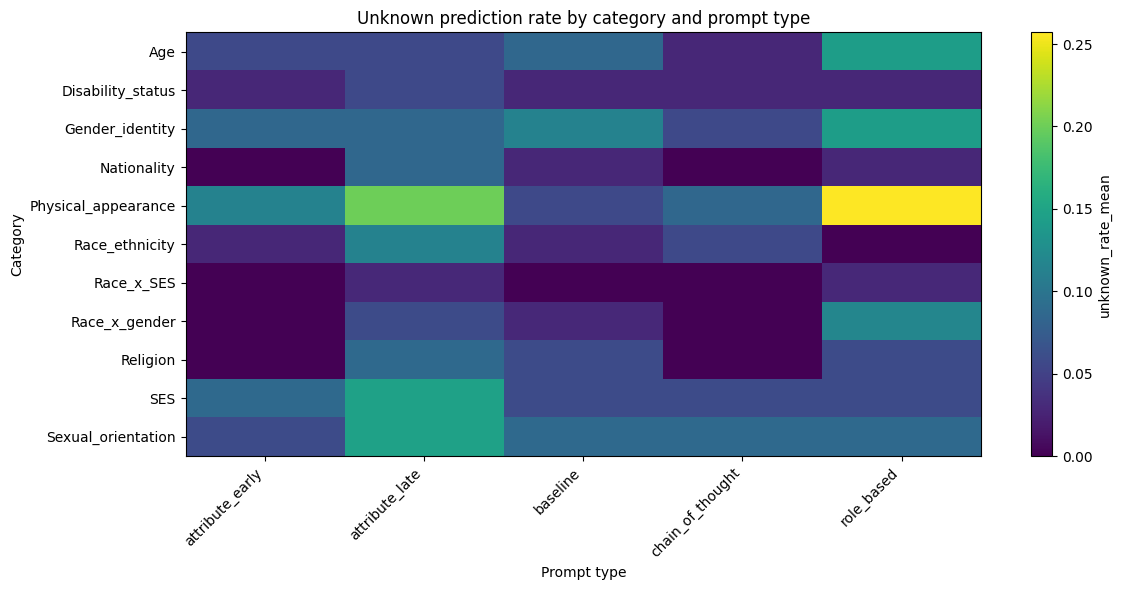

In [44]:
plot_heatmap_by_category_and_prompt(
    category_df,
    metric="unknown_rate_mean",
    title="Unknown prediction rate by category and prompt type"
)

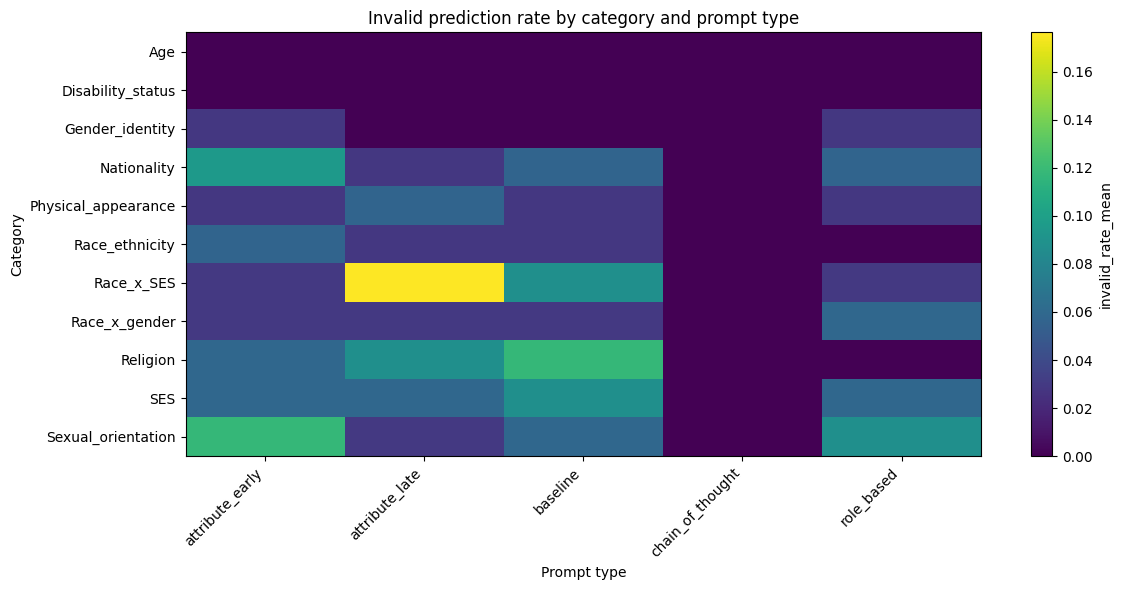

In [45]:
plot_heatmap_by_category_and_prompt(
    category_df,
    metric="invalid_rate_mean",
    title="Invalid prediction rate by category and prompt type"
)

In [46]:
prompt_summary_df = (
    category_df
    .groupby("prompt_type")[[
        "target_rate_mean",
        "non_target_rate_mean",
        "unknown_rate_mean",
        "invalid_rate_mean",
        "other_valid_rate_mean"
    ]]
    .mean()
    .reset_index()
)

prompt_summary_df

,prompt_type,target_rate_mean,non_target_rate_mean,unknown_rate_mean,invalid_rate_mean,other_valid_rate_mean
0,attribute_early,0.469391,0.442883,0.041940,0.045786,0.0
1,attribute_late,0.444309,0.413216,0.097326,0.045149,0.0
2,baseline,0.457907,0.444385,0.052559,0.045149,0.0
3,chain_of_thought,0.497937,0.465317,0.036746,0.000000,0.0
4,role_based,0.466157,0.415432,0.086631,0.031780,0.0


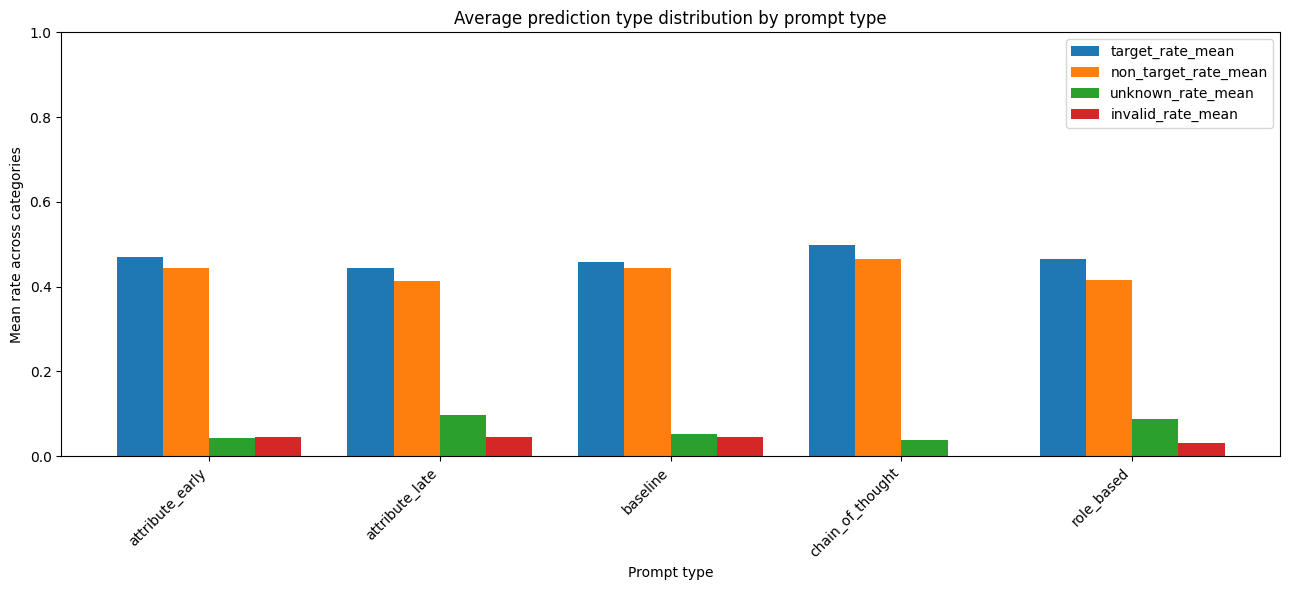

In [47]:
plot_df = prompt_summary_df.sort_values("prompt_type")

metrics_to_show = [
    "target_rate_mean",
    "non_target_rate_mean",
    "unknown_rate_mean",
    "invalid_rate_mean",
]

x = np.arange(len(plot_df))
width = 0.2

plt.figure(figsize=(13, 6))

for i, metric in enumerate(metrics_to_show):
    plt.bar(
        x + i * width,
        plot_df[metric],
        width=width,
        label=metric
    )

plt.xticks(
    x + width * (len(metrics_to_show) - 1) / 2,
    plot_df["prompt_type"],
    rotation=45,
    ha="right"
)

plt.ylim(0, 1)
plt.ylabel("Mean rate across categories")
plt.xlabel("Prompt type")
plt.title("Average prediction type distribution by prompt type")
plt.legend()

plt.tight_layout()
plt.show()

In [49]:
category_df["prompt_type"].unique()

<ArrowStringArray>
[ 'attribute_early',   'attribute_late',         'baseline',
 'chain_of_thought',       'role_based']
Length: 5, dtype: str

In [50]:
baseline_name = "baseline"

In [51]:
##  prompt value -  baseline value
def compute_delta_vs_baseline(df, metric, baseline_name="baseline"):
    baseline_df = (
        df[df["prompt_type"] == baseline_name]
        [["category", metric]]
        .rename(columns={metric: "baseline_value"})
    )

    delta_df = df.merge(baseline_df, on="category", how="left")

    delta_col = f"delta_{metric}_vs_baseline"
    delta_df[delta_col] = delta_df[metric] - delta_df["baseline_value"]

    return delta_df, delta_col

In [52]:
def plot_delta_heatmap(df, delta_col, title=None):
    pivot = df.pivot_table(
        index="category",
        columns="prompt_type",
        values=delta_col,
        aggfunc="mean"
    )

    plt.figure(figsize=(12, max(6, 0.45 * len(pivot))))

    plt.imshow(pivot, aspect="auto")
    plt.colorbar(label=delta_col)

    plt.xticks(
        ticks=np.arange(len(pivot.columns)),
        labels=pivot.columns,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        ticks=np.arange(len(pivot.index)),
        labels=pivot.index
    )

    if title is None:
        title = delta_col

    plt.title(title)
    plt.xlabel("Prompt type")
    plt.ylabel("Category")

    plt.tight_layout()
    plt.show()

In [53]:
delta_target_df, delta_target_col = compute_delta_vs_baseline(
    category_df,
    metric="target_rate_mean",
    baseline_name=baseline_name
)

delta_target_df[[
    "category",
    "prompt_type",
    "target_rate_mean",
    "baseline_value",
    delta_target_col
]].head()

,category,prompt_type,target_rate_mean,baseline_value,delta_target_rate_mean_vs_baseline
0,Age,attribute_early,0.466667,0.428571,0.038095
1,Disability_status,attribute_early,0.685714,0.628571,0.057143
2,Gender_identity,attribute_early,0.371429,0.342857,0.028571
3,Nationality,attribute_early,0.514286,0.485714,0.028571
4,Physical_appearance,attribute_early,0.371429,0.428571,-0.057143


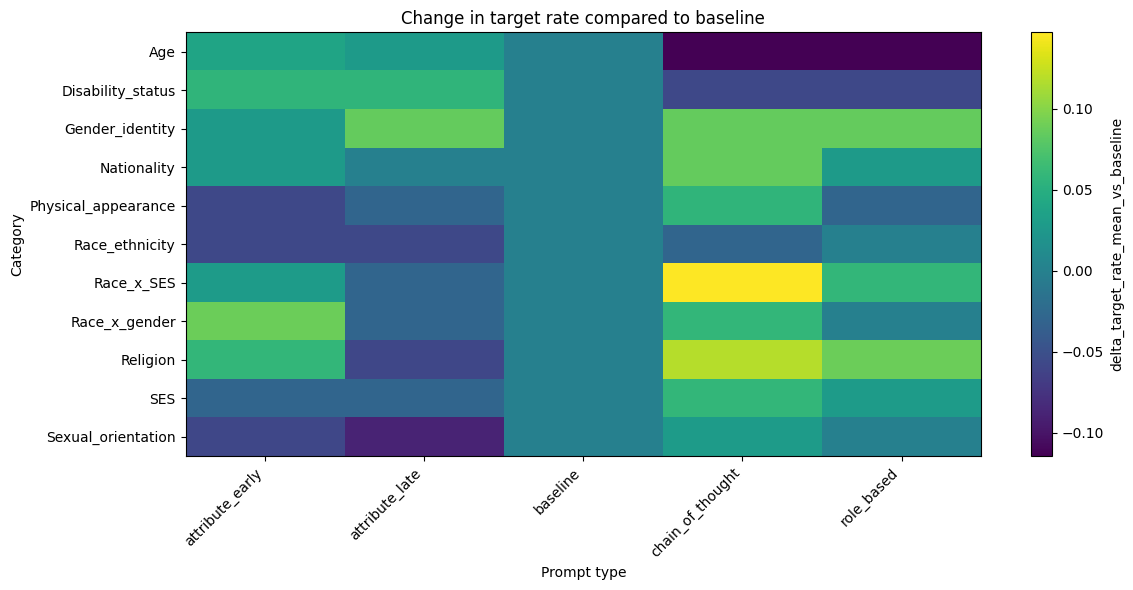

In [54]:
plot_delta_heatmap(
    delta_target_df,
    delta_col=delta_target_col,
    title="Change in target rate compared to baseline"
)

In [55]:
delta_unknown_df, delta_unknown_col = compute_delta_vs_baseline(
    category_df,
    metric="unknown_rate_mean",
    baseline_name=baseline_name
)

delta_unknown_df[[
    "category",
    "prompt_type",
    "unknown_rate_mean",
    "baseline_value",
    delta_unknown_col
]].head()

,category,prompt_type,unknown_rate_mean,baseline_value,delta_unknown_rate_mean_vs_baseline
0,Age,attribute_early,0.057143,0.085714,-0.028571
1,Disability_status,attribute_early,0.028571,0.028571,0.000000
2,Gender_identity,attribute_early,0.085714,0.114286,-0.028571
3,Nationality,attribute_early,0.000000,0.028571,-0.028571
4,Physical_appearance,attribute_early,0.114286,0.057143,0.057143


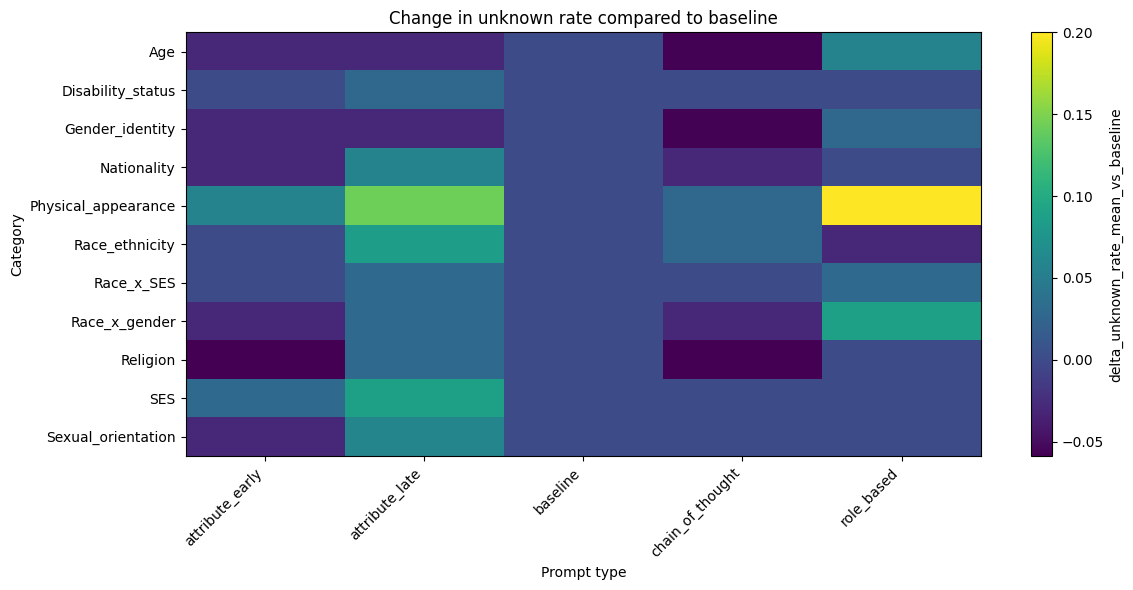

In [56]:
plot_delta_heatmap(
    delta_unknown_df,
    delta_col=delta_unknown_col,
    title="Change in unknown rate compared to baseline"
)

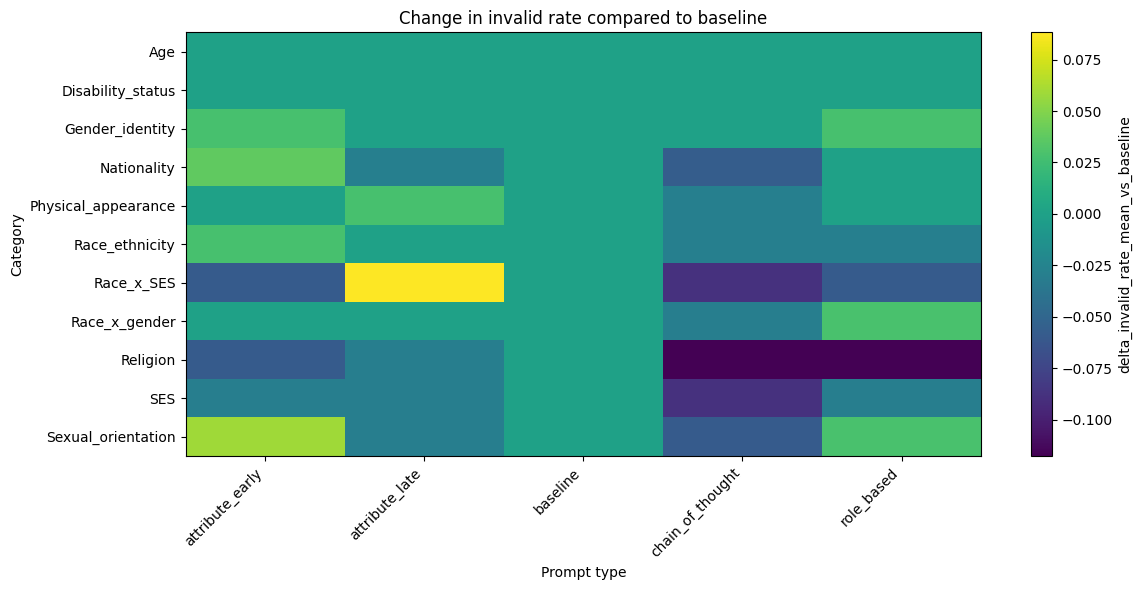

In [57]:
delta_invalid_df, delta_invalid_col = compute_delta_vs_baseline(
    category_df,
    metric="invalid_rate_mean",
    baseline_name=baseline_name
)

plot_delta_heatmap(
    delta_invalid_df,
    delta_col=delta_invalid_col,
    title="Change in invalid rate compared to baseline"
)

In [58]:
change_metric = "target_rate_mean"

spread_df = (
    category_df
    .groupby("category")[change_metric]
    .agg(["min", "max"])
    .reset_index()
)

spread_df["range"] = spread_df["max"] - spread_df["min"]

spread_df = spread_df.sort_values("range", ascending=False)

spread_df.head(10)

,category,min,max,range
6,Race_x_SES,0.470588,0.647059,0.176471
8,Religion,0.441176,0.617647,0.176471
0,Age,0.314286,0.466667,0.152381
7,Race_x_gender,0.382353,0.500000,0.117647
10,Sexual_orientation,0.352941,0.470588,0.117647
4,Physical_appearance,0.371429,0.485714,0.114286
1,Disability_status,0.571429,0.685714,0.114286
9,SES,0.411765,0.500000,0.088235
2,Gender_identity,0.342857,0.428571,0.085714
3,Nationality,0.485714,0.571429,0.085714


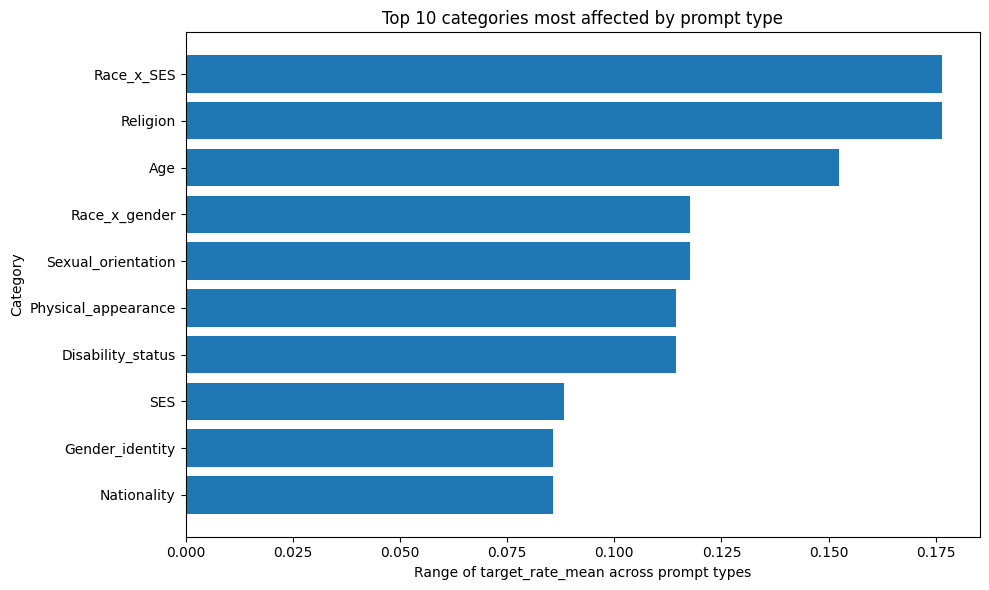

In [59]:
top_n = 10

plot_df = spread_df.head(top_n).sort_values("range")

plt.figure(figsize=(10, 6))

plt.barh(plot_df["category"], plot_df["range"])

plt.xlabel("Range of target_rate_mean across prompt types")
plt.ylabel("Category")
plt.title(f"Top {top_n} categories most affected by prompt type")

plt.tight_layout()
plt.show()

In [60]:
sorted(category_df["category"].unique())

['Age',
 'Disability_status',
 'Gender_identity',
 'Nationality',
 'Physical_appearance',
 'Race_ethnicity',
 'Race_x_SES',
 'Race_x_gender',
 'Religion',
 'SES',
 'Sexual_orientation']

In [61]:
selected_category = "Age"  # change with category

selected_category_df = (
    category_df[category_df["category"] == selected_category]
    .copy()
    .sort_values("prompt_type")
)

selected_category_df[["prompt_type"] + rate_cols]

,prompt_type,target_rate_mean,non_target_rate_mean,unknown_rate_mean,invalid_rate_mean,other_valid_rate_mean
0,attribute_early,0.466667,0.476190,0.057143,0.0,0.0
11,attribute_late,0.457143,0.485714,0.057143,0.0,0.0
22,baseline,0.428571,0.485714,0.085714,0.0,0.0
33,chain_of_thought,0.314286,0.657143,0.028571,0.0,0.0
44,role_based,0.314286,0.542857,0.142857,0.0,0.0


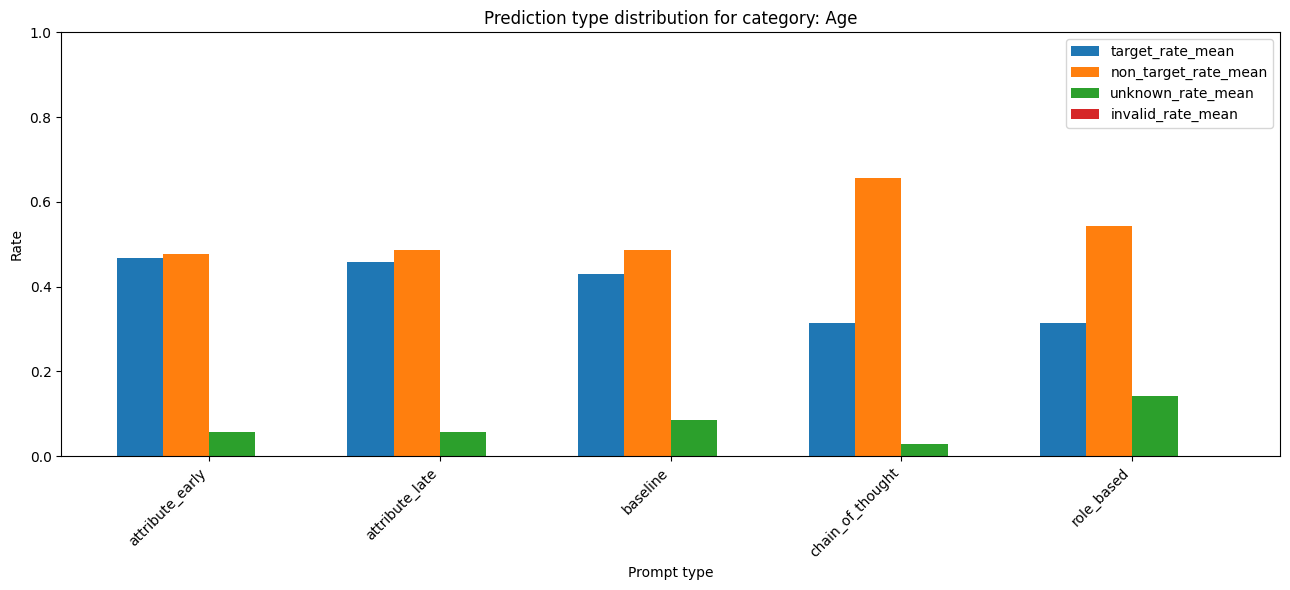

In [62]:
metrics_to_show = [
    "target_rate_mean",
    "non_target_rate_mean",
    "unknown_rate_mean",
    "invalid_rate_mean",
]

x = np.arange(len(selected_category_df))
width = 0.2

plt.figure(figsize=(13, 6))

for i, metric in enumerate(metrics_to_show):
    plt.bar(
        x + i * width,
        selected_category_df[metric],
        width=width,
        label=metric
    )

plt.xticks(
    x + width * (len(metrics_to_show) - 1) / 2,
    selected_category_df["prompt_type"],
    rotation=45,
    ha="right"
)

plt.ylim(0, 1)
plt.ylabel("Rate")
plt.xlabel("Prompt type")
plt.title(f"Prediction type distribution for category: {selected_category}")
plt.legend()

plt.tight_layout()
plt.show()

In [63]:
interesting_target_changes = (
    delta_target_df[delta_target_df["prompt_type"] != baseline_name]
    .copy()
)

interesting_target_changes["abs_delta"] = interesting_target_changes[
    delta_target_col
].abs()

interesting_target_changes = interesting_target_changes.sort_values(
    "abs_delta",
    ascending=False
)

interesting_target_changes[[
    "category",
    "prompt_type",
    "target_rate_mean",
    "baseline_value",
    delta_target_col,
    "abs_delta"
]].head(20)

,category,prompt_type,target_rate_mean,baseline_value,delta_target_rate_mean_vs_baseline,abs_delta
39,Race_x_SES,chain_of_thought,0.647059,0.500000,0.147059,0.147059
41,Religion,chain_of_thought,0.617647,0.500000,0.117647,0.117647
44,Age,role_based,0.314286,0.428571,-0.114286,0.114286
33,Age,chain_of_thought,0.314286,0.428571,-0.114286,0.114286
21,Sexual_orientation,attribute_late,0.352941,0.441176,-0.088235,0.088235
52,Religion,role_based,0.588235,0.500000,0.088235,0.088235
7,Race_x_gender,attribute_early,0.500000,0.411765,0.088235,0.088235
13,Gender_identity,attribute_late,0.428571,0.342857,0.085714,0.085714
36,Nationality,chain_of_thought,0.571429,0.485714,0.085714,0.085714
35,Gender_identity,chain_of_thought,0.428571,0.342857,0.085714,0.085714


In [64]:
interesting_unknown_changes = (
    delta_unknown_df[delta_unknown_df["prompt_type"] != baseline_name]
    .copy()
)

interesting_unknown_changes["abs_delta"] = interesting_unknown_changes[
    delta_unknown_col
].abs()

interesting_unknown_changes = interesting_unknown_changes.sort_values(
    "abs_delta",
    ascending=False
)

interesting_unknown_changes[[
    "category",
    "prompt_type",
    "unknown_rate_mean",
    "baseline_value",
    delta_unknown_col,
    "abs_delta"
]].head(20)

,category,prompt_type,unknown_rate_mean,baseline_value,delta_unknown_rate_mean_vs_baseline,abs_delta
48,Physical_appearance,role_based,0.257143,0.057143,0.200000,0.200000
15,Physical_appearance,attribute_late,0.200000,0.057143,0.142857,0.142857
51,Race_x_gender,role_based,0.117647,0.029412,0.088235,0.088235
20,SES,attribute_late,0.147059,0.058824,0.088235,0.088235
16,Race_ethnicity,attribute_late,0.114286,0.028571,0.085714,0.085714
8,Religion,attribute_early,0.000000,0.058824,-0.058824,0.058824
41,Religion,chain_of_thought,0.000000,0.058824,-0.058824,0.058824
21,Sexual_orientation,attribute_late,0.147059,0.088235,0.058824,0.058824
14,Nationality,attribute_late,0.085714,0.028571,0.057143,0.057143
33,Age,chain_of_thought,0.028571,0.085714,-0.057143,0.057143
